# 会员试用转化

## 1. 数据准备-- PSM/DiD 数据构造

### 1.1 PSM匹配

正在加载数据...
数据加载成功！
数据集1样本量: 5000
数据集2样本量: 70000

正在执行PSM匹配(with replacement)...
匹配完成: treat=2500, matched_control=2500

====== 匹配平衡性检验 (SMD) ======

匹配前：
covariate  mean_treat  mean_control      smd
   gender      0.4056        0.3948 0.022041
age_group      1.6568        1.6284 0.039381
play_time   2309.2252     2298.8680 0.020569

匹配后：
covariate  mean_treat  mean_control       smd
   gender      0.4056        0.4140 -0.017077
age_group      1.6568        1.6596 -0.003954
play_time   2309.2252     2296.3472  0.025652


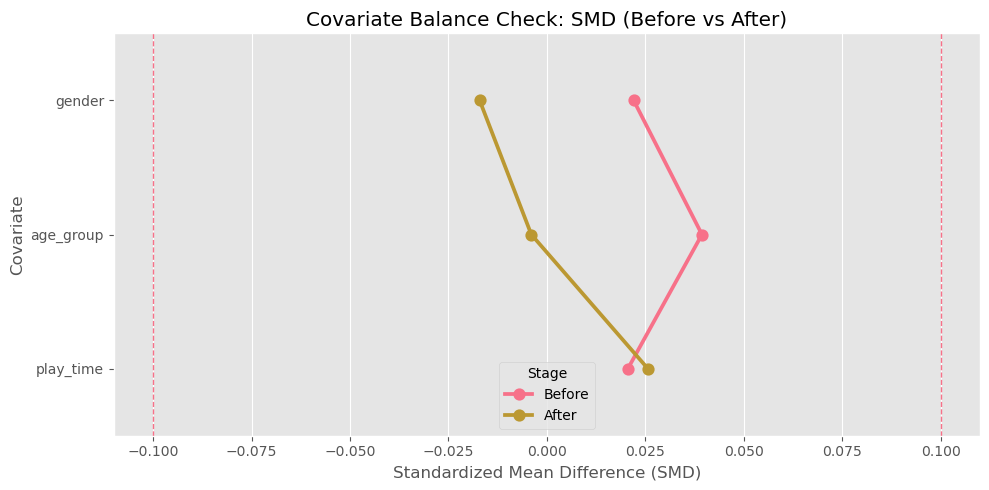

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from statsmodels.formula.api import ols

# ================= 0. 全局设置 =================
try:
    plt.style.use("seaborn")
except Exception:
    plt.style.use("ggplot")

sns.set_palette("husl")

# ================= 1. 数据准备 =================
print("正在加载数据...")
df1 = pd.read_csv("./项目文档-长视频APP会员试用转化PSM+DID/files/项目文档-长视频APP会员试用转化PSM+DID-dataset1_video_app_psm.csv")  # 用户特征 + group(0/1)
df2 = pd.read_csv("./项目文档-长视频APP会员试用转化PSM+DID/files/项目文档-长视频APP会员试用转化PSM+DID-dataset2_video_app_did.csv", dtype={"date": str})  # 面板数据

# 日期处理：确保 4 位，例如 '0901'
df2["date"] = df2["date"].astype(str).str.zfill(4)

# AA/AB 分期：你原来口径保持不变（0908 起为 post）
df2["post_period"] = (df2["date"] >= "0908").astype(int)

print("数据加载成功！")
print(f"数据集1样本量: {len(df1)}")
print(f"数据集2样本量: {len(df2)}")

# ================= 2. PSM 匹配（with replacement） =================
def psm_matching_with_replacement(data: pd.DataFrame, covariates, k=1, seed=2025):
    """
    倾向得分匹配（with replacement）
    - 同一个 control 允许被多个 treatment 匹配
    - 通过 NearestNeighbors 在 ps_score 上做最近邻匹配
    - 输出 matched_data，并给出 match_weight 便于后续加权估计（可选）
    """
    rng = np.random.RandomState(seed)

    df = data.copy()

    # 标准化协变量
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[covariates])

    # 估计倾向得分
    ps_model = LogisticRegression(max_iter=2000, random_state=seed)
    ps_model.fit(X_scaled, df["group"])
    df["ps_score"] = ps_model.predict_proba(X_scaled)[:, 1]

    treat = df[df["group"] == 1].copy()
    control = df[df["group"] == 0].copy()

    # 最近邻匹配（with replacement）
    nbrs = NearestNeighbors(n_neighbors=k, algorithm="ball_tree")
    nbrs.fit(control[["ps_score"]])

    distances, indices = nbrs.kneighbors(treat[["ps_score"]])

    matched_control = control.iloc[indices.flatten()].copy()
    matched_control["matched_id"] = np.repeat(treat.index.values, k)
    matched_control["match_weight"] = 1.0 / k

    treat["matched_id"] = treat.index
    treat["match_weight"] = 1.0

    matched_data = pd.concat([treat, matched_control], axis=0, ignore_index=False)

    return matched_data, ps_model, scaler

# 协变量
covariates = ["gender", "age_group", "play_time"]

print("\n正在执行PSM匹配(with replacement)...")
matched_data, ps_model, scaler = psm_matching_with_replacement(df1, covariates, k=1)

print(
    f"匹配完成: treat={int((matched_data['group']==1).sum())},",
    f"matched_control={int((matched_data['group']==0).sum())}"
)

# ================= 3. 匹配平衡性检验（SMD） =================
def compute_smd(data: pd.DataFrame, covariate: str):
    """
    标准化均值差 (SMD):
      SMD = (mean_t - mean_c) / sqrt((var_t + var_c)/2)
    """
    t = data[data["group"] == 1][covariate].dropna()
    c = data[data["group"] == 0][covariate].dropna()

    mean_t = t.mean()
    mean_c = c.mean()

    var_t = t.var(ddof=1)
    var_c = c.var(ddof=1)
    pooled = np.sqrt((var_t + var_c) / 2.0)

    smd = (mean_t - mean_c) / pooled if pooled > 0 else np.nan
    return mean_t, mean_c, smd

def balance_check_smd(before_df: pd.DataFrame, after_df: pd.DataFrame, covariates):
    rows_before = []
    rows_after = []

    for cov in covariates:
        mt, mc, smd = compute_smd(before_df, cov)
        rows_before.append([cov, mt, mc, smd])

        mt2, mc2, smd2 = compute_smd(after_df, cov)
        rows_after.append([cov, mt2, mc2, smd2])

    before_tbl = pd.DataFrame(rows_before, columns=["covariate", "mean_treat", "mean_control", "smd"])
    after_tbl = pd.DataFrame(rows_after, columns=["covariate", "mean_treat", "mean_control", "smd"])

    print("\n====== 匹配平衡性检验 (SMD) ======")
    print("\n匹配前：")
    print(before_tbl.to_string(index=False))
    print("\n匹配后：")
    print(after_tbl.to_string(index=False))

    # SMD Before vs After 图
    plot_df = pd.DataFrame({
        "covariate": covariates,
        "Before": before_tbl["smd"].values,
        "After": after_tbl["smd"].values
    }).melt(id_vars="covariate", var_name="Stage", value_name="SMD")

    plt.figure(figsize=(10, 5))
    sns.pointplot(data=plot_df, x="SMD", y="covariate", hue="Stage", join=True, markers="o")
    plt.axvline(0.1, linestyle="--", linewidth=1)
    plt.axvline(-0.1, linestyle="--", linewidth=1)
    plt.title("Covariate Balance Check: SMD (Before vs After)")
    plt.xlabel("Standardized Mean Difference (SMD)")
    plt.ylabel("Covariate")
    plt.tight_layout()
    plt.show()

    return before_tbl, after_tbl

before_smd, after_smd = balance_check_smd(df1, matched_data, covariates)

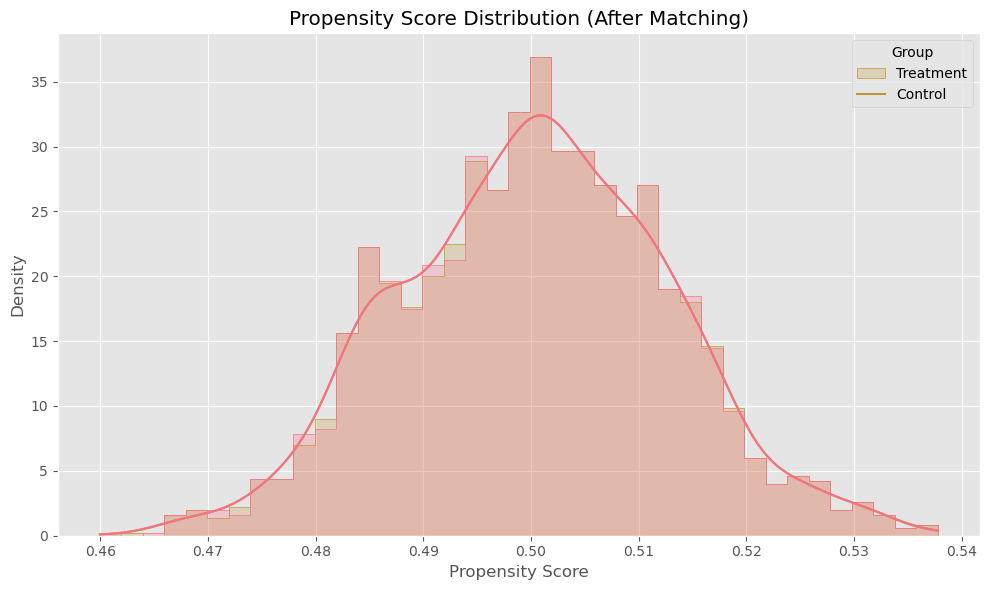

In [2]:
# ================= 4. 倾向得分分布图（After Matching） =================
plt.figure(figsize=(10, 6))
sns.histplot(
    data=matched_data,
    x="ps_score",
    hue="group",
    element="step",
    stat="density",
    common_norm=False,
    kde=True
)
plt.title("Propensity Score Distribution (After Matching)")
plt.xlabel("Propensity Score")
plt.ylabel("Density")
plt.legend(title="Group", labels=["Treatment", "Control"])
plt.tight_layout()
plt.show()

### 1.2 DiD


正在构造 DiD 面板（仅保留匹配后的用户）...
DiD面板样本量(匹配后用户过滤): 53424
匹配后用户数: 3816
group
1    35000
0    18424
Name: count, dtype: int64

====== 平行趋势检查 ======


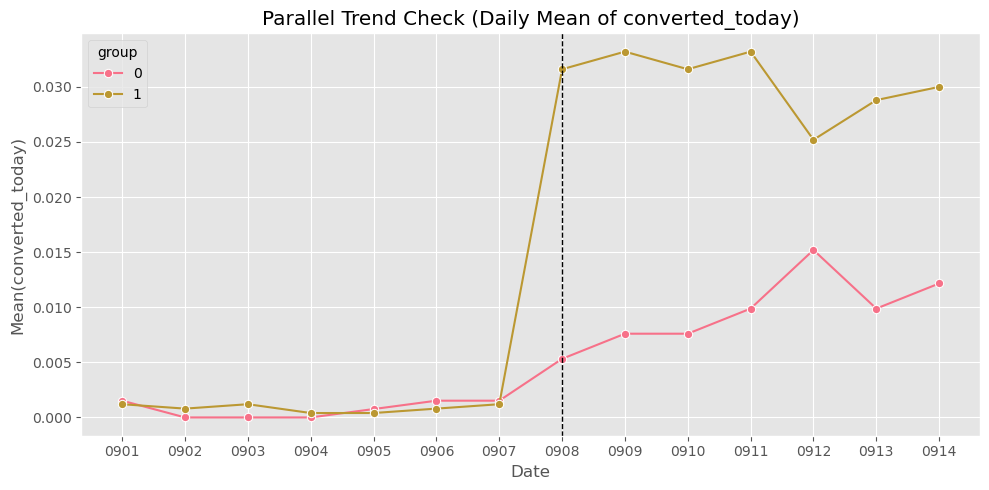


====== 平行趋势回归检验（仅 pre-period）======
                            OLS Regression Results                            
Dep. Variable:        converted_today   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.3211
Date:                Fri, 06 Mar 2026   Prob (F-statistic):              0.810
Time:                        19:40:32   Log-Likelihood:                 56961.
No. Observations:               26712   AIC:                        -1.139e+05
Df Residuals:                   26708   BIC:                        -1.139e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Int

In [3]:
# ================= 5. 将匹配后的样本映射进 DiD 面板 =================
print("\n正在构造 DiD 面板（仅保留匹配后的用户）...")

matched_users = matched_data["user_id"].dropna().unique()
df2_matched = df2[df2["user_id"].isin(matched_users)].copy()

# 把 group 补进 df2_matched（防止出现 group_x / group_y）
group_map = df1[["user_id", "group"]].drop_duplicates("user_id")

df2_matched = df2_matched.merge(
    group_map,
    on="user_id",
    how="left",
    suffixes=("", "_from_df1")
)

# 兼容：如果 df2 原本就有 group，merge 后会出现 group_from_df1
if "group_from_df1" in df2_matched.columns:
    # 优先用 df1 的 group（更可信）
    df2_matched["group"] = df2_matched["group_from_df1"]
    df2_matched.drop(columns=["group_from_df1"], inplace=True)

# 兜底：如果 merge 失败或 user_id 对不上，直接报更明确的错
if "group" not in df2_matched.columns:
    raise KeyError(
        "df2_matched 中仍然没有 group 列。请检查：df2 是否有 user_id 列、df1 的 user_id 是否能和 df2 对齐。"
    )

# 基础清洗
df2_matched["group"] = pd.to_numeric(df2_matched["group"], errors="coerce").fillna(0).astype(int)
df2_matched["post_period"] = df2_matched["post_period"].astype(int)

print(f"DiD面板样本量(匹配后用户过滤): {len(df2_matched)}")
print(f"匹配后用户数: {df2_matched['user_id'].nunique()}")
print(df2_matched["group"].value_counts(dropna=False))

# ================= 6. 平行趋势检验（图 + pre-period 回归） =================
print("\n====== 平行趋势检查 ======")

# 6.1 画每日均值趋势
daily = (
    df2_matched.groupby(["date", "group"])["converted_today"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=daily, x="date", y="converted_today", hue="group", marker="o")
plt.axvline("0908", linestyle="--", linewidth=1, color="k")
plt.title("Parallel Trend Check (Daily Mean of converted_today)")
plt.xlabel("Date")
plt.ylabel("Mean(converted_today)")
plt.tight_layout()
plt.show()

# 6.2 仅用 pre-period 做回归：converted_today ~ group + time_index + group:time_index
pre = df2_matched[df2_matched["post_period"] == 0].copy()

# 构造 time_index（按日期排序映射为 0,1,2,...）
sorted_dates = sorted(pre["date"].unique())
date_to_idx = {d: i for i, d in enumerate(sorted_dates)}
pre["time_index"] = pre["date"].map(date_to_idx).astype(int)

pre_model = ols("converted_today ~ group + time_index + group:time_index", data=pre).fit()

print("\n====== 平行趋势回归检验（仅 pre-period）======")
print(pre_model.summary())
print("\n重点看：group:time_index 的系数与 p-value（是否存在差异趋势）")

In [4]:
# ================= 7. DID 模型估计 =================
def compute_att(agg_data: pd.DataFrame):
    pre_t = agg_data[(agg_data.group == 1) & (agg_data.post_period == 0)]["converted_today"].mean()
    post_t = agg_data[(agg_data.group == 1) & (agg_data.post_period == 1)]["converted_today"].mean()
    pre_c = agg_data[(agg_data.group == 0) & (agg_data.post_period == 0)]["converted_today"].mean()
    post_c = agg_data[(agg_data.group == 0) & (agg_data.post_period == 1)]["converted_today"].mean()
    return (post_t - pre_t) - (post_c - pre_c)

def did_estimation_user_agg(data: pd.DataFrame):
    """
    DiD: 按 user_id x post_period 聚合
    注意：这里是简化点，后续可升级为 event/survival 或 post期是否转化等。
    """
    agg = data.groupby(["user_id", "post_period"]).agg(
        converted_today=("converted_today", "sum"),
        group=("group", "first")
    ).reset_index()

    agg["treat_post"] = agg["group"] * agg["post_period"]

    model = ols("converted_today ~ group + post_period + group:post_period", data=agg).fit()

    print("\n====== DiD OLS 结果 (user x pre/post 聚合）======")
    print(model.summary())

    att = compute_att(agg)
    print(f"\n平均处理效应(ATT): {att:.4f}")

    return model, agg, att

print("\nDiD模型估计结果: ")
did_model, did_agg, att = did_estimation_user_agg(df2_matched)


DiD模型估计结果: 

====== DiD OLS 结果 (user x pre/post 聚合）======
                            OLS Regression Results                            
Dep. Variable:        converted_today   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                     268.2
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          1.64e-165
Time:                        19:40:33   Log-Likelihood:                -1266.8
No. Observations:                7632   AIC:                             2542.
Df Residuals:                    7628   BIC:                             2569.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

## 2. Uplift圈选

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from causalml.inference.tree import UpliftRandomForestClassifier
from causalml.metrics import auuc_score
import matplotlib.pyplot as plt

# 1. 数据加载与预处理
ab_display = pd.read_excel('./项目文档-长视频APP会员试用转化PSM+DID/files/项目文档-长视频APP会员试用转化PSM+DID-数据集1.xlsx', sheet_name='Sheet1')
print(ab_display.head())

Failed to import duecredit due to No module named 'duecredit'


   Unnamed: 0        uid         组别      垂类 性别  年龄 消费水平   城市线  is_buy
0           0  616984329    control  体育-NFL  女  43    高  四线城市       0
1           1  489268482    control   体育-F1  女  55    低  二线城市       0
2           2  336292534    control  电视剧-武侠  女  44    中  一线城市       0
3           3  464612681  treatment  电视剧-武侠  男  47    高  二线城市       0
4           4  482072911  treatment  电视剧-武侠  女  44    中  二线城市       0


AUUC Score: 0.846786
整体Uplift: 0.031493


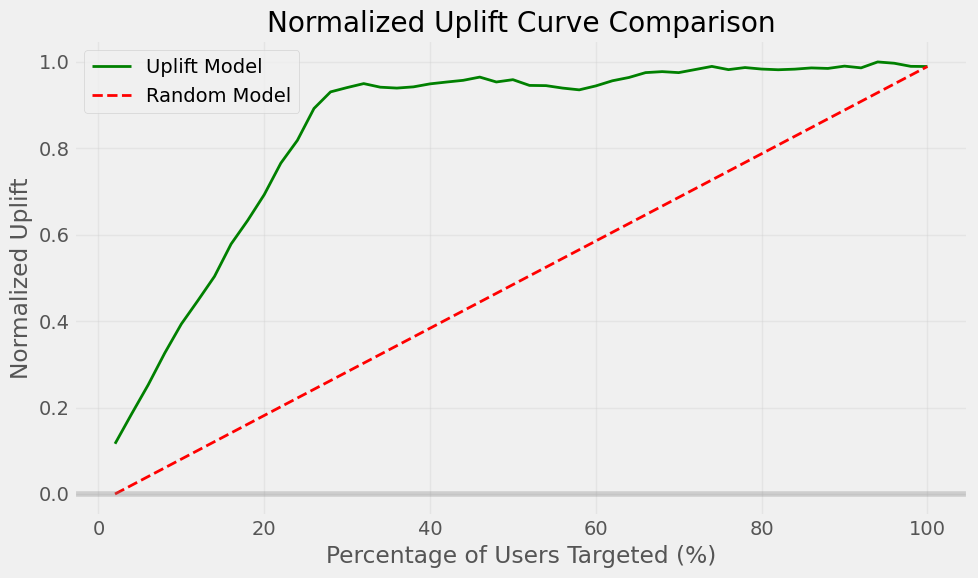

In [6]:
# 2. 分类变量编码
le = LabelEncoder()
ab_display['性别'] = le.fit_transform(ab_display['性别'])
ab_display['城市线'] = le.fit_transform(ab_display['城市线'])
ab_display['消费水平'] = le.fit_transform(ab_display['消费水平'])
ab_display['年龄'] = le.fit_transform(ab_display['年龄'])

# OneHot编码垂类
try:
    ohe = OneHotEncoder(sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(sparse=False)

category_ohe = ohe.fit_transform(ab_display[['垂类']])
category_columns = [f'category_{i}' for i in range(category_ohe.shape[1])]
category_df = pd.DataFrame(category_ohe, columns=category_columns)
ab_display = pd.concat([ab_display, category_df], axis=1).drop('垂类', axis=1)

# 3. 选择特征和目标变量
features = ['性别', '年龄', '消费水平', '城市线'] + category_columns
y = ab_display['is_buy']
treatment = ab_display['组别']
X = ab_display[features]

# 4. 划分训练集和测试集
X_train, X_test, y_train, y_test, treat_train, treat_test = train_test_split(
    X, y, treatment, 
    test_size=0.2, 
    random_state=42
)

# 5. 模型训练
model = UpliftRandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=8,
    min_samples_leaf=50,
    control_name='control'
)
model.fit(
    X=X_train.values,
    treatment=treat_train.values,
    y=y_train.values
)

# 6. 预测
y_pred = model.predict(X_test.values)
df_res = pd.DataFrame(y_pred, columns=['pred_lift'])

# 7. 准备评估数据
df_true = pd.DataFrame({
    '组别': treat_test,
    'is_buy': y_test
}).reset_index(drop=True)
df = pd.concat([df_res, df_true], axis=1)

# 8. 将treatment列转换为数值
df['treatment_numeric'] = (df['组别'] == 'treatment').astype(int)

# 9. 计算AUUC
try:
    score = auuc_score(
        df,
        treatment_col='treatment_numeric',
        outcome_col='is_buy',
        uplift_col='pred_lift'
    )
    if isinstance(score, pd.Series):
        score_value = score.iloc[0]
    else:
        score_value = float(score)
    print(f"AUUC Score: {score_value:.6f}")
except Exception as e:
    print(f"计算AUUC时出错: {e}")
    score_value = 0

# 10. 计算正确的Uplift曲线
def calculate_correct_uplift_curve(df, n_bins=100):
    """计算正确的Uplift曲线"""
    df_sorted = df.sort_values('pred_lift', ascending=False)
    n_samples = len(df_sorted)
    
    uplift_values = []
    percentages = []
    
    # 分箱计算，避免数值问题
    for i in range(1, n_bins + 1):
        percent = i * 100 / n_bins
        n_cut = int(n_samples * percent / 100)
        df_subset = df_sorted.head(n_cut)
        
        # 计算该分箱的Uplift
        treated_subset = df_subset[df_subset['treatment_numeric'] == 1]
        control_subset = df_subset[df_subset['treatment_numeric'] == 0]
        
        if len(treated_subset) > 0 and len(control_subset) > 0:
            treated_rate = treated_subset['is_buy'].mean()
            control_rate = control_subset['is_buy'].mean()
            uplift = (treated_rate - control_rate) * n_cut  # 累积效应
        else:
            uplift = 0
            
        uplift_values.append(uplift)
        percentages.append(percent)
    
    return percentages, uplift_values

# 计算正确的曲线
percentages, uplift_values = calculate_correct_uplift_curve(df, n_bins=50)

# 计算随机模型的Uplift曲线（均匀分布）
random_uplift = np.linspace(0, uplift_values[-1], len(uplift_values))

# 计算整体Uplift（用于验证交点）
overall_treated_rate = df[df['treatment_numeric']==1]['is_buy'].mean()
overall_control_rate = df[df['treatment_numeric']==0]['is_buy'].mean()
overall_uplift = overall_treated_rate - overall_control_rate

print(f"整体Uplift: {overall_uplift:.6f}")

# 绘制仅Normalized Uplift Curve并添加random model
plt.figure(figsize=(10, 6))

# 标准化处理
if len(uplift_values) > 0:
    max_uplift = max(abs(u) for u in uplift_values) or 1
    normalized_uplift = [u/max_uplift for u in uplift_values]
    normalized_random = [r/max_uplift for r in random_uplift]
else:
    normalized_uplift = uplift_values
    normalized_random = random_uplift

# 绘制标准化Uplift曲线
plt.plot(percentages, normalized_uplift, 'g-', label='Uplift Model', linewidth=2)
plt.plot(percentages, normalized_random, 'r--', label='Random Model', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('Percentage of Users Targeted (%)')
plt.ylabel('Normalized Uplift')
plt.title('Normalized Uplift Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. A/B实验检测

In [7]:
ab_people= pd.read_excel('./项目文档-长视频APP会员试用转化PSM+DID/files/项目文档-长视频APP会员试用转化PSM+DID-数据集2_长视频AB_Test.xlsx')

#aa显著性检验
from scipy import stats

# 定义需要进行 t 检验的观测变量
variables = ['aa人均播放时长', 'aa人均app时长', 'aaCTR' , 'aaLT7', 'aaLTV7','aa是否转化']

# 创建一个空的列表，用于存储结果
results = []

# 对每个变量进行 t 检验
for var in variables:
    # 分组：实验组（组别 == 1）和对照组（组别 == 0）
    treatment_group = ab_people[ab_people['组别'] == 'treatment'][var]
    control_group = ab_people[ab_people['组别'] == 'control'][var]
    # 进行双尾 t 检验
    t_stat, p_value = stats.ttest_ind(treatment_group, control_group, equal_var=False)
    # 计算均值差值
    mean_diff = treatment_group.mean() - control_group.mean()
    # 判断统计显著性
    significance = '显著' if p_value < 0.05 else '不显著'
    # 将结果存储在列表中
    results.append({
    '变量': var,
    '实验组均值': treatment_group.mean(),
    '对照组均值': control_group.mean(),
    '均值差值': mean_diff,
    't统计量': t_stat,
    'p值': p_value,
    '是否统计显著': significance
    })

# 将结果转换为 DataFrame
results_df = pd.DataFrame(results)

# 格式化输出（例如设置浮动数字的显示格式）
results_df = results_df.style.format({
'实验组均值': '{:.4f}',
'对照组均值': '{:.4f}',
'均值差值': '{:.4f}',
't统计量': '{:.4f}',
'p值': '{:.4f}'
})

# 输出结果
results_df

,变量,实验组均值,对照组均值,均值差值,t统计量,p值,是否统计显著
0,aa人均播放时长,2034.4574,2029.4390,5.0185,0.8636,0.3878,不显著
1,aa人均app时长,3090.6036,3088.6935,1.9101,0.3015,0.7630,不显著
2,aaCTR,0.4507,0.4512,-0.0005,-0.5016,0.6159,不显著
3,aaLT7,4.0048,4.0003,0.0045,0.5373,0.5911,不显著
4,aaLTV7,6.3674,6.4148,-0.0474,-1.6406,0.1009,不显著
5,aa是否转化,0.0303,0.0308,-0.0005,-0.6524,0.5141,不显著


In [8]:
from scipy import stats

# 定义需要进行 t 检验的观测变量
variables = ['ab人均播放时长', 'ab人均app时长', 'abCTR', 'abLT7', 'abLTV7','ab是否转化']

# 创建一个空的列表，用于存储结果
results = []

# 对每个变量进行 t 检验
for var in variables:
    # 分组：实验组（组别 == 'treatment'）和对照组（组别 == 'control'）
    treatment_group = ab_people[ab_people['组别'] == 'treatment'][var]
    control_group = ab_people[ab_people['组别'] == 'control'][var]
    # 进行双尾 t 检验
    t_stat, p_value = stats.ttest_ind(treatment_group, control_group, equal_var=False)
    # 计算均值差值
    mean_diff = treatment_group.mean() - control_group.mean()
    # 判断统计显著性
    significance = '显著' if p_value < 0.05 else '不显著'
    # 将结果存储在列表中
    results.append({
    '变量': var,
    '实验组均值': treatment_group.mean(),
    '对照组均值': control_group.mean(),
    '均值差值': mean_diff,
    't统计量': t_stat,
    'p值': p_value,
    '是否统计显著': significance
    })
    
# 将结果转换为 DataFrame
results_df = pd.DataFrame(results)

# 格式化输出（例如设置浮动数字的显示格式）
results_df = results_df.style.format({
'实验组均值': '{:.4f}',
'对照组均值': '{:.4f}',
'均值差值': '{:.4f}',
't统计量': '{:.4f}',
'p值': '{:.4f}'
})

# 输出结果
results_df

,变量,实验组均值,对照组均值,均值差值,t统计量,p值,是否统计显著
0,ab人均播放时长,2340.6357,1854.8844,485.7513,78.0896,0.0000,显著
1,ab人均app时长,3025.6234,2814.5137,211.1098,31.5199,0.0000,显著
2,abCTR,0.4904,0.4509,0.0395,37.6212,0.0000,显著
3,abLT7,4.1119,4.0360,0.0759,9.0079,0.0000,显著
4,abLTV7,6.4023,6.3698,0.0325,1.1242,0.2609,不显著
5,ab是否转化,0.0522,0.0313,0.0209,21.6669,0.0000,显著
